## **i. Introduction**

1. Name       : Fawwaz Rif'at Revista
2. Batch      : RMT-039
3. Objective  : A region in Indonesia recently experienced forest and land fires that caused many losses, both materially, economically, psychologically, etc. The magnitude of these losses was caused by the lack of preventive measures prepared by the government before the fire occurred. Therefore, the government wants to prevent the same incident from happening again by focusing first on areas with a high risk of fire by grouping areas with a high risk of fire using satellite images. To achieve this, a machine learning model is needed that can predict the risk of fire based on existing images.

## **ii. Import Libraries**

In [1]:
# Downgrade version of TensorFlow and tf-keras

!pip install -q --upgrade "tensorflow<2.16" "tf-keras<2.16"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 475.3/475.3 MB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 31.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 49.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 49.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 58.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.0/442.0 kB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 6.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-text 2.18.1 requires tensorflow<2.19,>=2.18.0, but you have tensorflow 2.15.1 which is incompatible.
dopamine-rl 4.1.2 requires tf-keras>=2.18.0, but you have tf-keras 2.15.1 which is incompatible.


In [2]:
# Import libraries

import os
import cv2
import glob
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import random
import shutil
import tensorflow as tf

from collections import Counter
from PIL import Image
from PIL import ImageFile
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dense, Dropout, Conv2D, MaxPooling2D, Flatten, Input, BatchNormalization

from sklearn.metrics import confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

# Check TensorFlow version
print(tf.__version__)

2.15.1


## **iii. Data Loading**

In [3]:
%%time
# Download Dataset
# Source of dataset : https://www.kaggle.com/datasets/abdelghaniaaba/wildfire-prediction-dataset/data?select=test
# Download dataset
!kaggle datasets download -d abdelghaniaaba/wildfire-prediction-dataset

Dataset URL: https://www.kaggle.com/datasets/abdelghaniaaba/wildfire-prediction-dataset
License(s): other
 99% 1.43G/1.45G [00:11<00:00, 188MB/s]
100% 1.45G/1.45G [00:11<00:00, 138MB/s]
CPU times: user 179 ms, sys: 37.8 ms, total: 217 ms
Wall time: 12.8 s


In [4]:
# Unzip the dataset that haven been downloaded

!unzip -qq ./wildfire-prediction-dataset.zip

In [5]:
# Define the of dataset path
main_path = '/content/'
train_path = os.path.join(main_path, 'train')
valid_path = os.path.join(main_path, 'valid')
test_path = os.path.join(main_path, 'test')

The dataset has been separated between train, valid, and test, so that's mean doesn't need to divide train data to train and valid.

In [6]:
# Check how many data in train_path, valid_path, and test_path

def check_path(path):
  labels = os.listdir(path)
  for label in labels:
    num_data = len(os.listdir(os.path.join(path, label)))
    print(f'Total Data - {label} : {num_data}')

# Print amount of data in train_path
print('Train Path')
check_path(train_path)
print('')

# Print amount of data in valid_path
print('Validation Path')
check_path(valid_path)
print('')

# Print amount of data in test_path
print('Test Path')
check_path(test_path)
print('')

Train Path
Total Data - wildfire : 15750
Total Data - nowildfire : 14500

Validation Path
Total Data - wildfire : 3480
Total Data - nowildfire : 2820

Test Path
Total Data - wildfire : 3480
Total Data - nowildfire : 2820



In [7]:
# Taking only 20% of all data
# Define the data path
folders = {
    "train": "/content/train",
    "valid": "/content/valid",
    "test": "/content/test"
}

# Define the data path after selection
output_base = "/content/new_data"
os.makedirs(output_base, exist_ok=True)

for folder_name, input_folder in folders.items():
    output_folder = os.path.join(output_base, folder_name)
    os.makedirs(output_folder, exist_ok=True)

    # Label category checking
    categories = [cat for cat in os.listdir(input_folder) if os.path.isdir(os.path.join(input_folder, cat))]

    for category in categories:
        input_category_folder = os.path.join(input_folder, category)
        output_category_folder = os.path.join(output_folder, category)

        os.makedirs(output_category_folder, exist_ok=True)

        all_files = [f for f in os.listdir(input_category_folder) if os.path.isfile(os.path.join(input_category_folder, f))]

        if len(all_files) == 0:
            print(f"Tidak ada file dalam kategori {category} di {folder_name}")
            continue

        # Taking only 20% of total data
        sample_size = int(0.2 * len(all_files))

        # Taking random data/file
        random.seed(42) # Make the random data always same
        selected_files = random.sample(all_files, sample_size)

        # Copy the new data into new folder
        for file in selected_files:
            shutil.copy(os.path.join(input_category_folder, file), os.path.join(output_category_folder, file))

        print(f"{len(selected_files)} dari {len(all_files)} file dipilih untuk kategori {category} di folder {folder_name}")

print("Dataset baru berhasil dibuat di:", output_base)


3150 dari 15750 file dipilih untuk kategori wildfire di folder train
2900 dari 14500 file dipilih untuk kategori nowildfire di folder train
696 dari 3480 file dipilih untuk kategori wildfire di folder valid
564 dari 2820 file dipilih untuk kategori nowildfire di folder valid
696 dari 3480 file dipilih untuk kategori wildfire di folder test
564 dari 2820 file dipilih untuk kategori nowildfire di folder test
Dataset baru berhasil dibuat di: /content/new_data


## **iv. Exploratory Data Analysis (EDA)**

**Checking Data Balanced and Error Data**

In [8]:
# Define new data path
new_path = '/content/new_data'
train_path = os.path.join(new_path, 'train')
valid_path = os.path.join(new_path, 'valid')
test_path = os.path.join(new_path, 'test')

In [9]:
# Check how many data in new_data folder that consists of train_path, valid_path, and test_path after
def check_path(path):
  labels = os.listdir(path)
  for label in labels:
    num_data = len(os.listdir(os.path.join(path, label)))
    print(f'Total Data - {label} : {num_data}')

# Print amount of data in train_path
print('Train Path')
check_path(train_path)
print('')

# Print amount of data in valid_path
print('Validation Path')
check_path(valid_path)
print('')

# Print amount of data in test_path
print('Test Path')
check_path(test_path)
print('')

Train Path
Total Data - wildfire : 3150
Total Data - nowildfire : 2900

Validation Path
Total Data - wildfire : 696
Total Data - nowildfire : 564

Test Path
Total Data - wildfire : 696
Total Data - nowildfire : 564



In [10]:
# Checking if there ara error/corrupt data in dataset
def count_corrupt_images(directory):
    corrupt_count = 0  # Initilisation amount of broken image/data
    total_count = 0    # Initilisation amount of total image/data

    for root, _, files in os.walk(directory):
        for file in files:
            img_path = os.path.join(root, file)
            total_count += 1  # Counting all data/image
            try:
                with Image.open(img_path) as img:
                    img.verify()  # Verification of data validation
            except (IOError, SyntaxError):
                print(f"❌ Gambar rusak: {img_path}")
                corrupt_count += 1  # Counting total of broken image/data

    print(f"Jumlah gambar total di {directory}: {total_count}")
    print(f"Jumlah gambar rusak: {corrupt_count}")
    return corrupt_count

# Checking amount of corrupt/error/broken data at each dataset
train_corrupt = count_corrupt_images("/content/new_data/train")
valid_corrupt = count_corrupt_images("/content/new_data/valid")
test_corrupt = count_corrupt_images("/content/new_data/test")


Jumlah gambar total di /content/new_data/train: 6050
Jumlah gambar rusak: 0
Jumlah gambar total di /content/new_data/valid: 1260
Jumlah gambar rusak: 0
Jumlah gambar total di /content/new_data/test: 1260
Jumlah gambar rusak: 0


**Color, Shape, and Angle**

Based on the amount of data in each class, it is known that the dataset is included in the balanced data category because the amount of data in the nowildfire and wildfire classes is almost the same where the data is almost 50-50. In addition, checking is also carried out regarding error data so that if there is error data, it can be resolved before modeling.

In [11]:
# Made the function to visualize 5 image of 2 class
def plot_images(path):
  labels = os.listdir(path)
  for label in labels:
    folder_path = os.path.join(path, label)
    fig = plt.figure(figsize=(20, 20))
    columns = 5
    rows = 1
    print('Class : ', label)
    images = os.listdir(folder_path)
    for index in range(1, columns*rows +1):
        fig.add_subplot(rows, columns, index)
        image = plt.imread(os.path.join(folder_path, images[index]))
        plt.imshow(image)
        plt.axis("off")
    plt.show()

Class :  wildfire


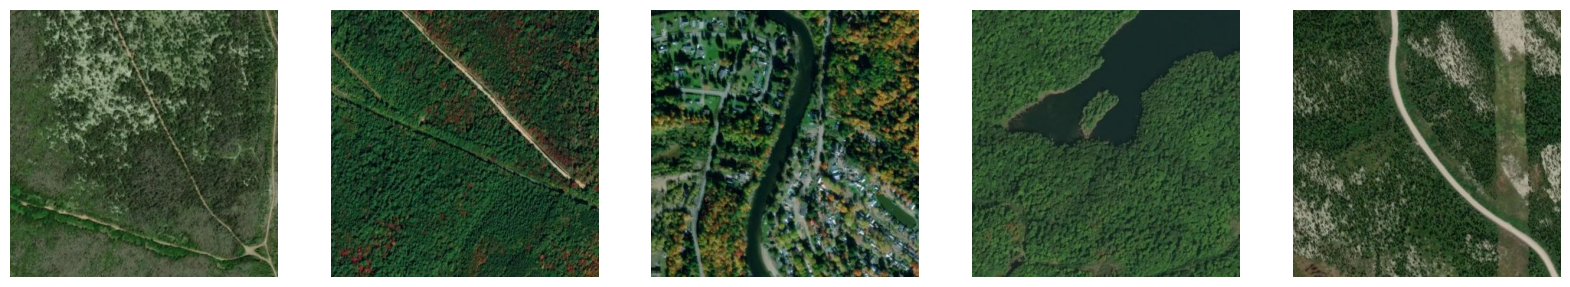

Class :  nowildfire


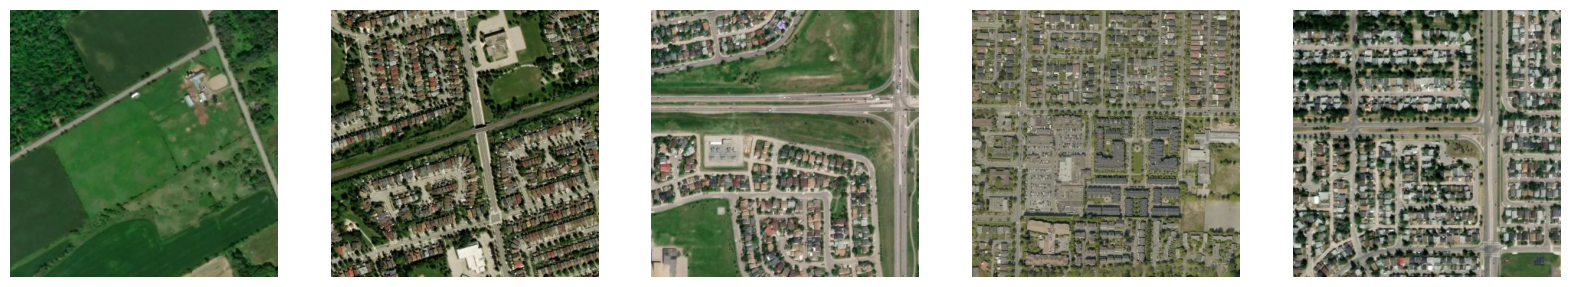

In [12]:
# Visualization of train_path
plot_images(train_path)

Class :  wildfire


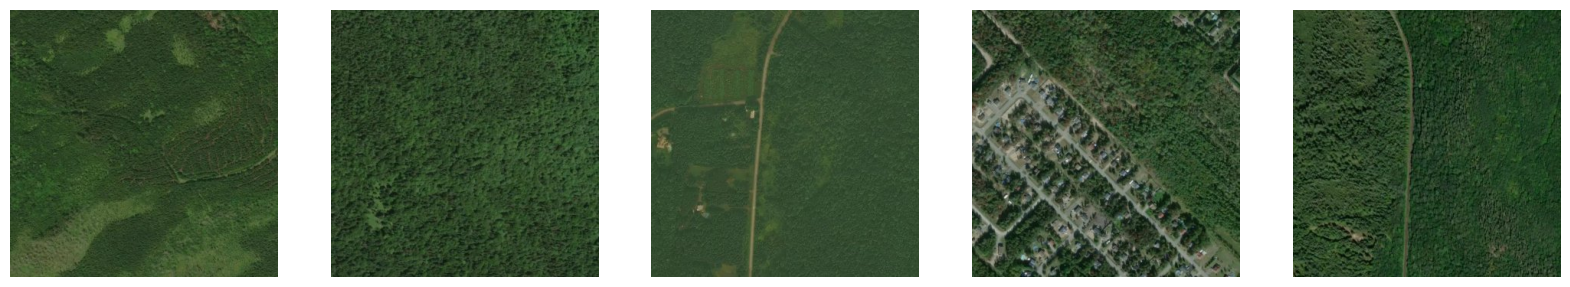

Class :  nowildfire


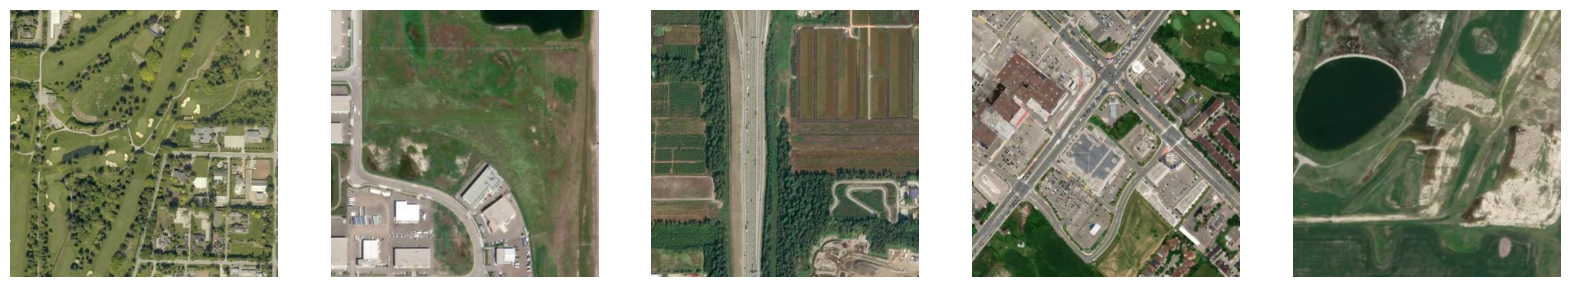

In [13]:
# Visualization of valid_path
plot_images(valid_path)

Class :  wildfire


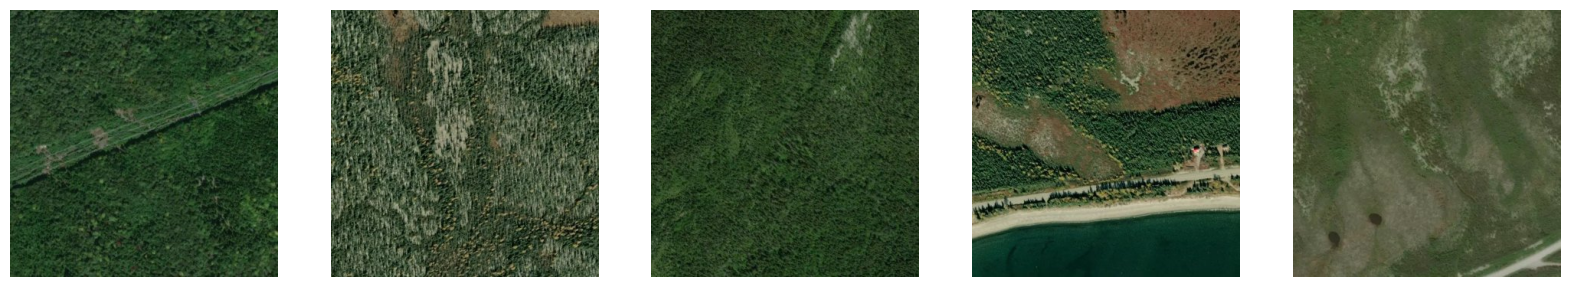

Class :  nowildfire


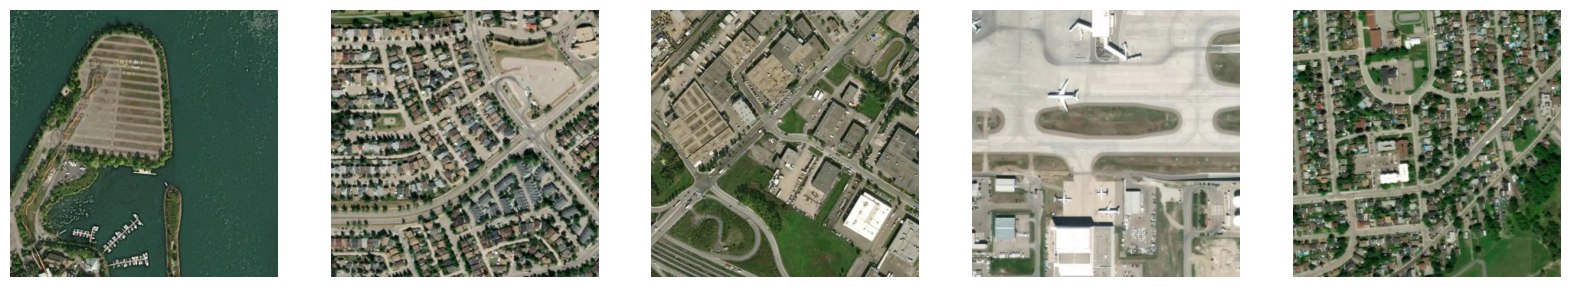

In [14]:
# Visualization of test_path
plot_images(test_path)

Based on the image above, we can see the difference in the wildfire and nowildfire images. Areas with a high risk of forest fires have more forest areas than buildings and roads, where the forest is dominated by the green color of the trees, while in areas with a low risk of forest fires are dominated by buildings and roads that are dominated by gray and brown. In addition, based on the angle of the image, it can be seen that all angles are pointing upwards or all images are taken at the same angle, namely from above.

**Size**

In [15]:
# Checking the image size even though at kaggle the data size is 350, but nedeed to check again
def check_image_sizes(directory):
    size_counter = Counter()  # Saving image based on size
    total_images = 0  # Counting amount of images

    for root, _, files in os.walk(directory):
        for file in files:
            img_path = os.path.join(root, file)
            try:
                with Image.open(img_path) as img:
                    size_counter[img.size] += 1  # Saving image size
                    total_images += 1
            except (IOError, SyntaxError):
                print(f"⚠️ Tidak bisa membaca gambar: {img_path}")

    print(f"📌 Total gambar di {directory}: {total_images}")
    print("📏 Ukuran gambar yang ditemukan:")
    for size, count in size_counter.items():
        print(f"   {size} -> {count} gambar")

    return size_counter

# Check the images size at each dataset
train_sizes = check_image_sizes("/content/new_data/train")
valid_sizes = check_image_sizes("/content/new_data/valid")
test_sizes = check_image_sizes("/content/new_data/test")


📌 Total gambar di /content/new_data/train: 6050
📏 Ukuran gambar yang ditemukan:
   (350, 350) -> 6050 gambar
📌 Total gambar di /content/new_data/valid: 1260
📏 Ukuran gambar yang ditemukan:
   (350, 350) -> 1260 gambar
📌 Total gambar di /content/new_data/test: 1260
📏 Ukuran gambar yang ditemukan:
   (350, 350) -> 1260 gambar


Based on the results of re-checking the image size, it is known that all images in the dataset, both train, valid, and test, have the same size, namely 350, so there is no need to make any further size adjustments.

## **v. Feature Engineering**

In [ ]:
# Define hyperparameters
img_height= 350 # 350 based on the real size
img_width= 350 # 350 based on the real size
batch_size= 64

Image size is very important to note so that all images have the same size, so that they can be analyzed properly by the model.

In [ ]:
# Create batch generator for train-set, val-set, and test-set
# Using Image.File to fix problem at the data/image, only the image that have probem if there are
ImageFile.LOAD_TRUNCATED_IMAGES = True

# Made the imagedatagenerator variable
train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255.,
                                                                rotation_range=35,
                                                                zoom_range=0.1,
                                                                shear_range=0.05)


train_set = train_datagen.flow_from_directory(train_path,
                                              target_size=(img_height,img_width),
                                              class_mode='binary',
                                              batch_size=batch_size,
                                              shuffle=True,
                                              seed=2)

val_set = train_datagen.flow_from_directory(valid_path,
                                            target_size=(img_height,img_width),
                                            class_mode='binary',
                                            batch_size=batch_size,
                                            shuffle=True,
                                            seed=2)

test_datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255.)

test_set = test_datagen.flow_from_directory(test_path,
                                            target_size=(img_height,img_width),
                                            class_mode='binary',
                                            batch_size=batch_size,
                                            shuffle=False,
                                            seed=2)

Found 6050 images belonging to 2 classes.
Found 1260 images belonging to 2 classes.
Found 1260 images belonging to 2 classes.


In order for the resulting model to be able to make better predictions, the images used must be more varied because in reality in the field the images obtained are not always of good quality. Therefore, in order for the model to be able to predict correctly even though the data/images used are not appropriate, the model must be trained with conditions that are likely to occur later.
Rotation range is used so that the model can learn if the image given is rotated. Zoom range is used so that the model can learn if the image is enlarged or reduced. In addition, shear range is also used so that the model can learn from tilted images.
The class mode used is binary because there are only 2 labels/targets, namely 0="nowildfire" and 1="wildfire".

In [ ]:
# Show labels of the train_set
train_set.class_indices

{'nowildfire': 0, 'wildfire': 1}

## **vi. ANN Training (Sequential API)**

**vi.1.Model Definition**

The CNN model is made using several layers such as convolutional layers, maxpool layers, flatten layers, and dense layers. In addition, each layer other than the output layer uses the RELU activation function which is chosen because it is an activation function that is commonly used for output layers with the Sigmoid activation function. RELU is also chosen so that the resulting values ​​are more varied/unlimited before being activated with Sigmoid.
The evaluation metric used is accuracy because the government has limited funds and wants to focus first on high-risk areas, so the accuracy evaluation metric is chosen so that the model created later can predict accurately and correctly because it considers TP, TN, FP, and FN to be equally important. In addition, the dataset used is balanced, so accuracy is more suitable for use.

In [38]:
# Clear session
seed = 20
tf.keras.backend.clear_session()
np.random.seed(seed)
tf.random.set_seed(seed)

In [39]:
# Create Sequential API model
model = tf.keras.models.Sequential()
model.add(Conv2D(4, (3,3), activation='relu', input_shape=(img_height, img_width,3)))
model.add(MaxPooling2D(2, 2))
model.add(Conv2D(8, (3,3), activation='relu'))
model.add(MaxPooling2D(2, 2))
model.add(Flatten())
model.add(Dropout(0.5))
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='sigmoid')) # Target/label is 2 class

# Compile
model.compile(loss='binary_crossentropy', # Based on Sigmoid
              optimizer='adam',
              metrics=['accuracy'])
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 348, 348, 4)       112       
                                                                 
 max_pooling2d (MaxPooling2  (None, 174, 174, 4)       0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 172, 172, 8)       296       
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 86, 86, 8)         0         
 g2D)                                                            
                                                                 
 flatten (Flatten)           (None, 59168)             0         
                                                                 
 dropout (Dropout)           (None, 59168)             0

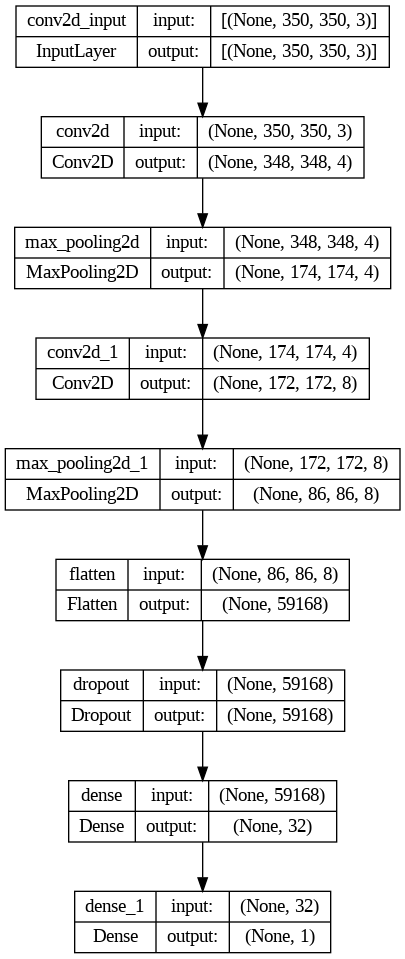

In [40]:
# Plot layers

tf.keras.utils.plot_model(model, show_shapes=True)

**vi.2.Model Training**

In [ ]:
# Train the model

%%time
history = model.fit(train_set, epochs=22, validation_data=val_set, batch_size=batch_size)

Epoch 1/22
95/95 [==============================] - 362s 4s/step - loss: 0.4017 - accuracy: 0.8393 - val_loss: 0.2394 - val_accuracy: 0.8976
Epoch 2/22
95/95 [==============================] - 361s 4s/step - loss: 0.2464 - accuracy: 0.9021 - val_loss: 0.1928 - val_accuracy: 0.9214
Epoch 3/22
95/95 [==============================] - 364s 4s/step - loss: 0.2338 - accuracy: 0.9094 - val_loss: 0.1783 - val_accuracy: 0.9286
Epoch 4/22
95/95 [==============================] - 364s 4s/step - loss: 0.2177 - accuracy: 0.9157 - val_loss: 0.1736 - val_accuracy: 0.9333
Epoch 5/22
95/95 [==============================] - 364s 4s/step - loss: 0.2127 - accuracy: 0.9149 - val_loss: 0.1610 - val_accuracy: 0.9349
Epoch 6/22
95/95 [==============================] - 357s 4s/step - loss: 0.2113 - accuracy: 0.9165 - val_loss: 0.1964 - val_accuracy: 0.9262
Epoch 7/22
95/95 [==============================] - 356s 4s/step - loss: 0.2029 - accuracy: 0.9197 - val_loss: 0.2184 - val_accuracy: 0.9119
Epoch 8/22
95

Based on the results of the training data train and validation, it can be seen that the results obtained are quite good where the loss generated in each epoch decreases and the accuracy increases, although there is a little volatility there, but the numbers produced are better than in the first epoch.

**vi.3.Model Evaluation**

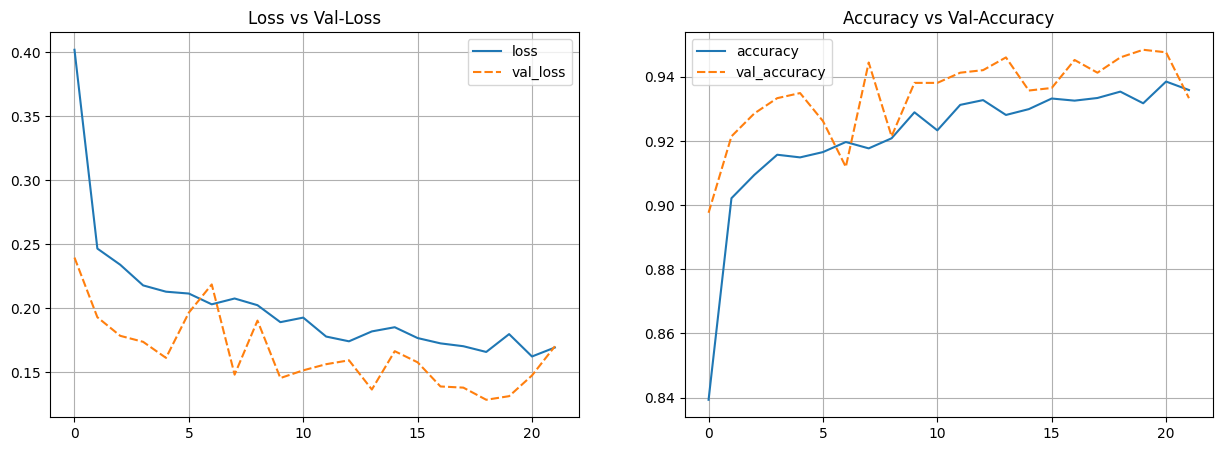

In [ ]:
# Plot training results

history_df = pd.DataFrame(history.history)

plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
sns.lineplot(data=history_df[['loss', 'val_loss']])
plt.grid()
plt.title('Loss vs Val-Loss')

plt.subplot(1, 2, 2)
sns.lineplot(data=history_df[['accuracy', 'val_accuracy']])
plt.grid()
plt.title('Accuracy vs Val-Accuracy')
plt.show()

In [ ]:
# Check the performance of test-set

# Get the probability
y_pred_prob = model.predict(test_set)

# For binary classification
y_pred_class = (y_pred_prob >= 0.5).astype(int)  # Convert probabilities into class labels

# Display Classification Report
print(classification_report(test_set.classes, y_pred_class, target_names=list(train_set.class_indices.keys())))

Based on the evaluation results, it can be seen that in the graph that there is still sufficient volatility in val_loss and val_accuracy, but visualization is a subjective assessment. Therefore, the accuracy evaluation metric is used to evaluate the model, based on the accuracy score obtained, it can be seen that the model is quite good at predicting, but still needs to be improved such as using batch normalization, etc.

## **vii. ANN Improvement (Sequential API)**

**vii.2.Model Definition**

The CNN model in this improvement has more layers and neurons to help the model learn more complex data. In addition, at this improvement stage, batchnormalization is also used and the Dropout number is increased from 0.5 to 0.7 to reduce overfit in the model. In addition, the hyperparameters used are the same as the previous model.

In [16]:
# Define hyperparameters
img_height= 350 # 350 based on the real size
img_width= 350 # 350 based on the real size
batch_size= 64

In [17]:
# Create batch generator for train-set, val-set, and test-set
# Using Image.File to fix problem at the data/image, only the image that have probem if there are
ImageFile.LOAD_TRUNCATED_IMAGES = True

# Made the imagedatagenerator variable
train_datagen_aug = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255.,
                                                                    rotation_range=35,
                                                                    zoom_range=0.1,
                                                                    shear_range=0.05)


train_set_aug = train_datagen_aug.flow_from_directory(train_path,
                                                      target_size=(img_height,img_width),
                                                      class_mode='binary',
                                                      batch_size=batch_size,
                                                      shuffle=True,
                                                      seed=2)

val_set_aug = train_datagen_aug.flow_from_directory(valid_path,
                                                    target_size=(img_height,img_width),
                                                    class_mode='binary',
                                                    batch_size=batch_size,
                                                    shuffle=True,
                                                    seed=2)

test_datagen_aug = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255.)

test_set_aug = test_datagen_aug.flow_from_directory(test_path,
                                                    target_size=(img_height,img_width),
                                                    class_mode='binary',
                                                    batch_size=batch_size,
                                                    shuffle=False,
                                                    seed=2)

Found 6050 images belonging to 2 classes.
Found 1260 images belonging to 2 classes.
Found 1260 images belonging to 2 classes.


In [18]:
# Clear session

seed = 20
tf.keras.backend.clear_session()
np.random.seed(seed)
tf.random.set_seed(seed)

In [19]:
# Create Sequential API model with improvement at the amount of layer & neuron, dropout number, and batchnormalization

model_aug = tf.keras.models.Sequential()
model_aug.add(Conv2D(8, (3,3), activation='relu', input_shape=(img_height, img_width,3)))
model_aug.add(BatchNormalization())
model_aug.add(MaxPooling2D(2, 2))
model_aug.add(Conv2D(16, (3,3), activation='relu'))
model_aug.add(BatchNormalization())
model_aug.add(MaxPooling2D(2, 2))
model_aug.add(Conv2D(32, (3,3), activation='relu'))
model_aug.add(BatchNormalization())
model_aug.add(MaxPooling2D(2, 2))
model_aug.add(Flatten())
model_aug.add(Dropout(0.7))
model_aug.add(Dense(64, activation='relu'))
model_aug.add(Dense(1, activation='sigmoid')) # Target/label is 2 class

# Compile
model_aug.compile(loss='binary_crossentropy', # Based on Sigmoid
              optimizer='adam',
              metrics=['accuracy'])
model_aug.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 348, 348, 8)       224       
                                                                 
 batch_normalization (Batch  (None, 348, 348, 8)       32        
 Normalization)                                                  
                                                                 
 max_pooling2d (MaxPooling2  (None, 174, 174, 8)       0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 172, 172, 16)      1168      
                                                                 
 batch_normalization_1 (Bat  (None, 172, 172, 16)      64        
 chNormalization)                                                
                                                        

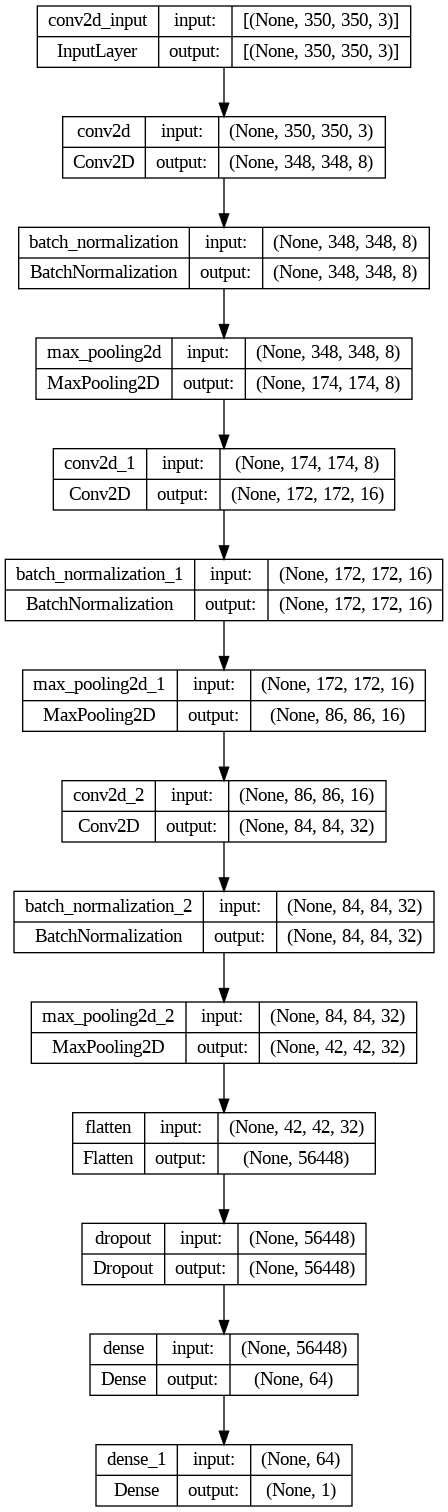

In [20]:
# Plot layers
tf.keras.utils.plot_model(model_aug, show_shapes=True)

**vii.2.Model Training**

In [23]:
# Train the model
%%time
# Used early stopping to prevent overfit
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
history_aug = model_aug.fit(train_set_aug, epochs=3, validation_data=val_set_aug, batch_size=batch_size, callbacks=[early_stop])

Epoch 1/3
95/95 [==============================] - 943s 10s/step - loss: 0.1920 - accuracy: 0.9258 - val_loss: 0.8607 - val_accuracy: 0.5524
Epoch 2/3
95/95 [==============================] - 869s 9s/step - loss: 0.1915 - accuracy: 0.9261 - val_loss: 0.4402 - val_accuracy: 0.7841
Epoch 3/3
95/95 [==============================] - 967s 10s/step - loss: 0.1766 - accuracy: 0.9301 - val_loss: 0.4362 - val_accuracy: 0.8254
CPU times: user 1h 39s, sys: 8min 14s, total: 1h 8min 53s
Wall time: 47min 14s


**viii.3.Model Training**

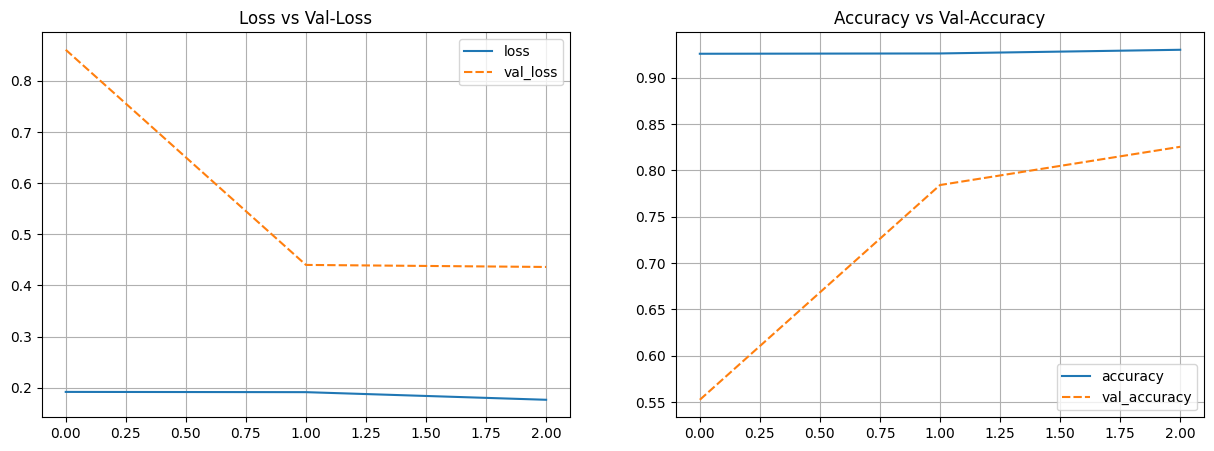

In [24]:
# Plot training results

history_aug_df = pd.DataFrame(history_aug.history)

plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
sns.lineplot(data=history_aug_df[['loss', 'val_loss']])
plt.grid()
plt.title('Loss vs Val-Loss')

plt.subplot(1, 2, 2)
sns.lineplot(data=history_aug_df[['accuracy', 'val_accuracy']])
plt.grid()
plt.title('Accuracy vs Val-Accuracy')
plt.show()

In [29]:
# Check the performance of test-set

# Get the probability
y_pred_prob = model_aug.predict(test_set_aug)

# For binary classification
y_pred_class = (y_pred_prob >= 0.5).astype(int)  # Convert probabilities into class labels

# Display Classification Report
print(classification_report(test_set_aug.classes, y_pred_class, target_names=list(train_set_aug.class_indices.keys())))

20/20 [==============================] - 58s 3s/step
              precision    recall  f1-score   support

  nowildfire       0.86      0.94      0.90       564
    wildfire       0.95      0.88      0.91       696

    accuracy                           0.90      1260
   macro avg       0.90      0.91      0.90      1260
weighted avg       0.91      0.90      0.90      1260



Based on the graph above, it can be concluded that the performance of the model after improvement is underfit, this is caused by the epoch being too small, but based on the visualization we can see that the plot has a pattern that tends to form goodfit if more epochs are used. Evaluation based on this visualization is subjective, so an evaluation metric accuracy value is needed. Based on the accuracy value obtained, it is known that the value obtained is 0.9 where this value is close to the value of the previous model performance, but in terms of training time, this model is faster, which is around 47 minutes where the previous model was around 2 hours more. This can be said to be an improvement because with much fewer epochs it can produce a model with the same performance with a faster time. The drawback of this model is of course that the epochs are too few, these too few epochs are caused by the laptop's performance which is not too good which results in a very long training time, so it cannot produce the best model.

## **viii. Model Saving**

In [34]:
# Saving model
model_aug.save("model_cnn.h5")

In [37]:
# Download model
from google.colab import files
files.download("model_cnn.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## **ix. Conclusion**

Based on the analysis results, at a glance we can distinguish areas that have a wildfire risk or not, namely based on the number of trees in the image, the more trees, the greener the image will be. In areas with a low risk of wildfire, the image of the area will be dominated by gray and brown which are the colors of roads/asphalt, buildings, and vacant land that have a small risk of burning.
The model obtained after improvement is the best model and was chosen because with a much smaller epoch it can produce a model with similar/the same performance with a training time that is not much different (> 1 hour). The weakness of the resulting model is the very small epoch, therefore, the epoch must be improved again.
The government can already use this model in determining areas with a wildfire risk, but it is recommended that the model be trained with more epochs and the recommended improvement is sufficient to increase the epoch without changing other hyperparameters.